In [79]:
import os

print(os.getcwd())
print(os.listdir("../data"))

c:\Users\BITPATNA\OneDrive\Desktop\heart-disease-ai\ml\notebooks
['processed.cleveland.data']


In [80]:
import os

print(os.getcwd())
print(os.listdir("../data"))

c:\Users\BITPATNA\OneDrive\Desktop\heart-disease-ai\ml\notebooks
['processed.cleveland.data']


In [81]:
import pandas as pd
import numpy as np

columns = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "target"
]

df = pd.read_csv(
    "../data/processed.cleveland.data",
    names=columns,
    na_values="?"
)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [82]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [83]:
print("Dataset shape:", df.shape)

Dataset shape: (303, 14)


In [84]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

In [85]:
na_values="?"

In [86]:
print(df["target"].value_counts().sort_index())

target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64


# Check the missing values

In [87]:
print("Missing values before cleaning:")
print(df.isnull().sum())

Missing values before cleaning:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


In [88]:
# Filling the missing valus

In [89]:
df["ca"] = df["ca"].fillna(df["ca"].median())
df["thal"] = df["thal"].fillna(df["thal"].median())

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [90]:
df["target"] = df["target"].apply(lambda x: 1 if x > 0 else 0)

In [91]:
print(df["target"].value_counts())

target
0    164
1    139
Name: count, dtype: int64


In [92]:
print("\nTarget percentage:")
print(df["target"].value_counts(normalize=True) * 100)


Target percentage:
target
0    54.125413
1    45.874587
Name: proportion, dtype: float64


In [93]:
#check the cleaned dataset

In [94]:
print("Dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

Dataset shape: (303, 14)

Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Data types:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object


In [95]:
#check the duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [96]:
df = df.drop_duplicates()

In [97]:
print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (303, 14)


In [98]:
# final cleaned dataset

In [99]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [100]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.663366,4.722772,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.934375,1.938383,0.499120
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


In [101]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Visualization libraries loaded!")

Visualization libraries loaded!


target
0    164
1    139
Name: count, dtype: int64


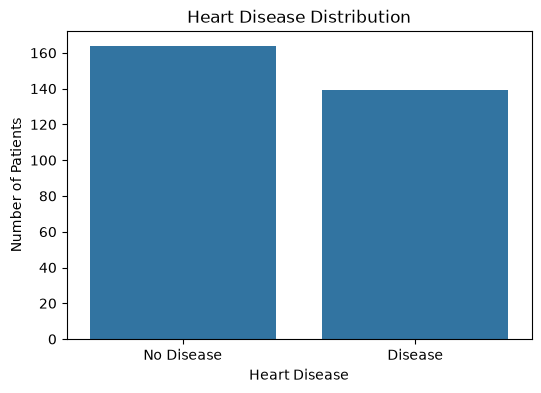

In [102]:
print(df["target"].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x="target", data=df)

plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Number of Patients")
plt.xticks([0, 1], ["No Disease", "Disease"])

plt.show()

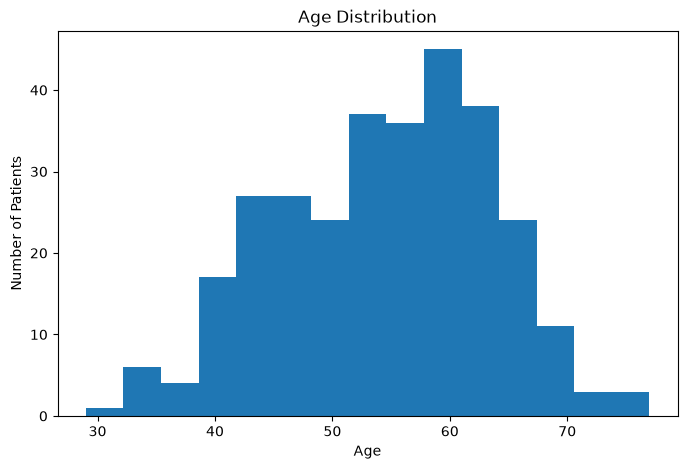

In [103]:
plt.figure(figsize=(8, 5))

plt.hist(df["age"], bins=15)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.show()

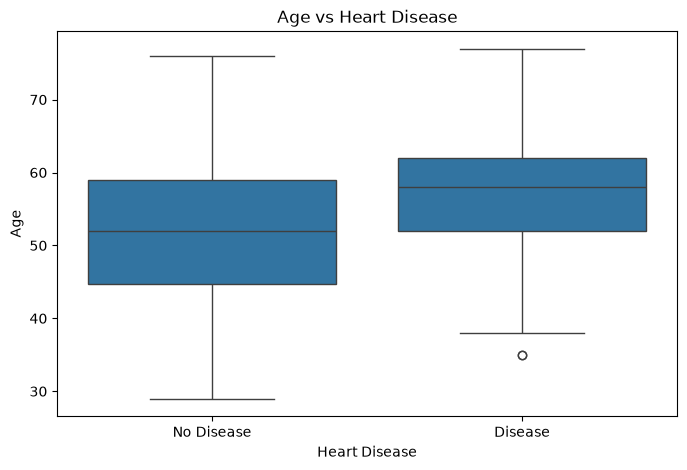

In [104]:
plt.figure(figsize=(8, 5))

sns.boxplot(x="target", y="age", data=df)

plt.title("Age vs Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Age")
plt.xticks([0, 1], ["No Disease", "Disease"])

plt.show()

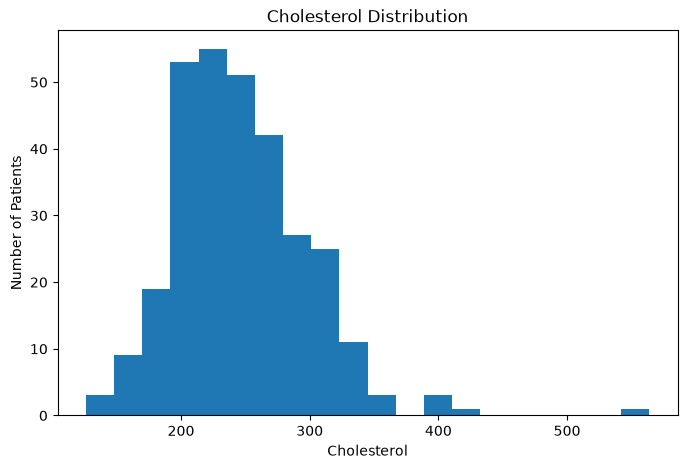

In [105]:
plt.figure(figsize=(8, 5))

plt.hist(df["chol"], bins=20)

plt.title("Cholesterol Distribution")
plt.xlabel("Cholesterol")
plt.ylabel("Number of Patients")

plt.show()

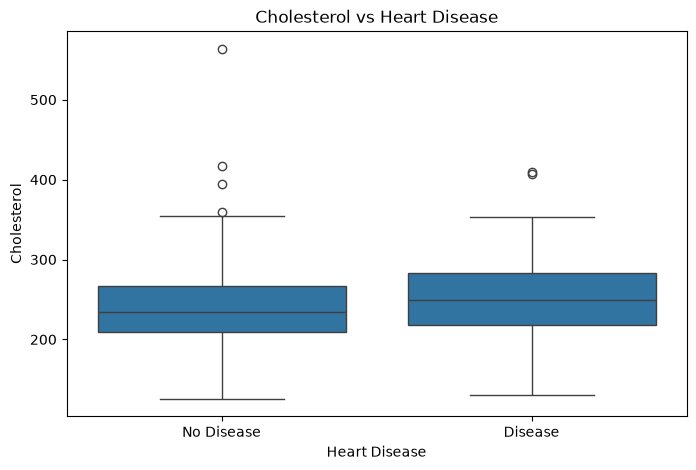

In [106]:
plt.figure(figsize=(8, 5))

sns.boxplot(x="target", y="chol", data=df)

plt.title("Cholesterol vs Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Cholesterol")
plt.xticks([0, 1], ["No Disease", "Disease"])

plt.show()

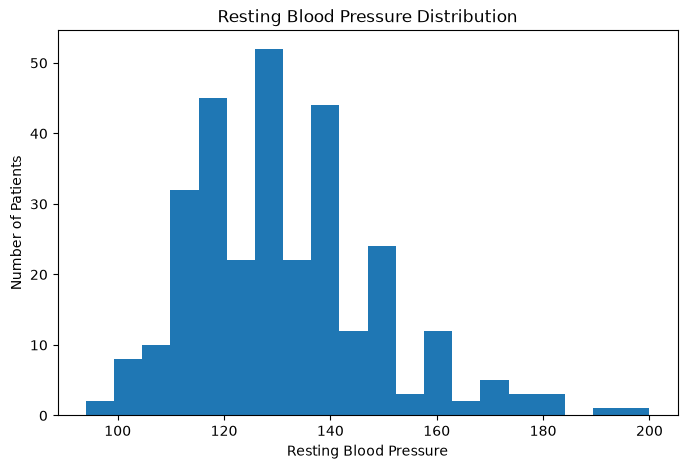

In [107]:
plt.figure(figsize=(8, 5))

plt.hist(df["trestbps"], bins=20)

plt.title("Resting Blood Pressure Distribution")
plt.xlabel("Resting Blood Pressure")
plt.ylabel("Number of Patients")

plt.show()

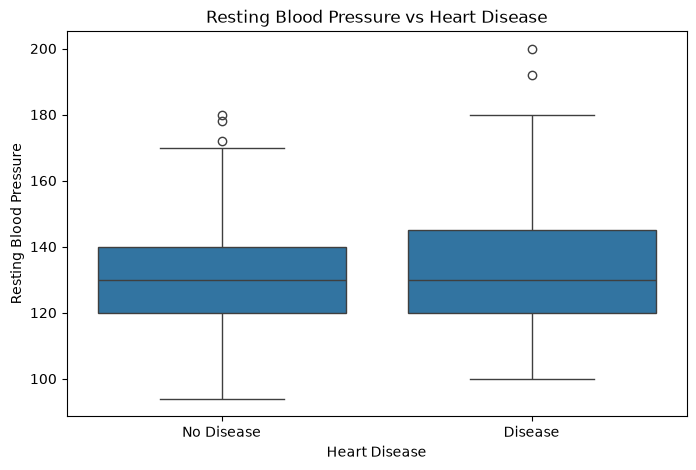

In [108]:
plt.figure(figsize=(8, 5))

sns.boxplot(x="target", y="trestbps", data=df)

plt.title("Resting Blood Pressure vs Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Resting Blood Pressure")
plt.xticks([0, 1], ["No Disease", "Disease"])

plt.show()

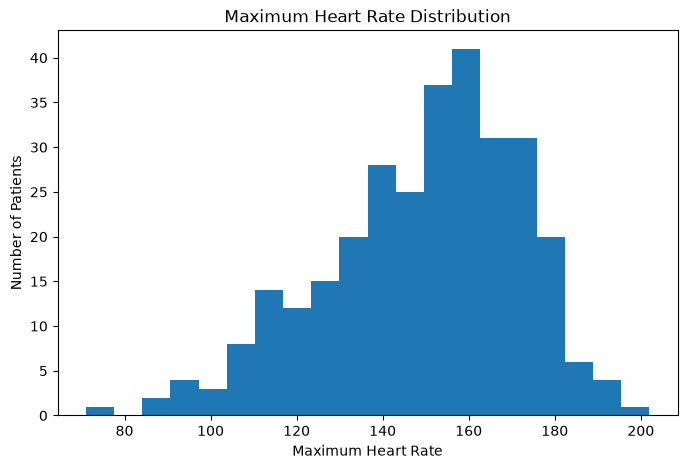

In [109]:
plt.figure(figsize=(8, 5))

plt.hist(df["thalach"], bins=20)

plt.title("Maximum Heart Rate Distribution")
plt.xlabel("Maximum Heart Rate")
plt.ylabel("Number of Patients")

plt.show()

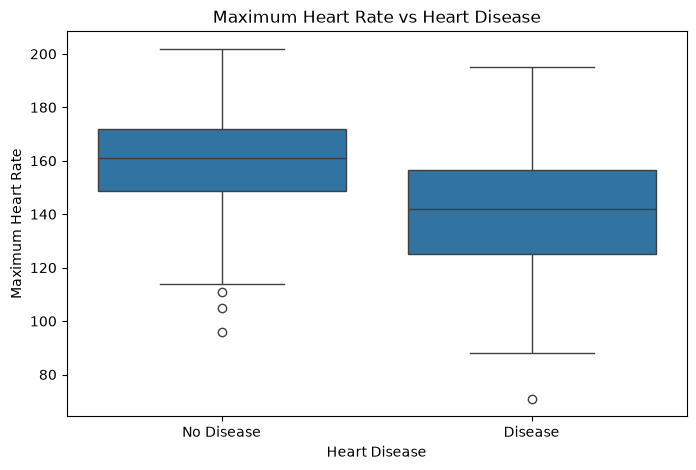

In [110]:
plt.figure(figsize=(8, 5))

sns.boxplot(x="target", y="thalach", data=df)

plt.title("Maximum Heart Rate vs Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Maximum Heart Rate")
plt.xticks([0, 1], ["No Disease", "Disease"])

plt.show()

In [111]:
print(pd.crosstab(df["sex"], df["target"]))

target   0    1
sex            
0.0     72   25
1.0     92  114


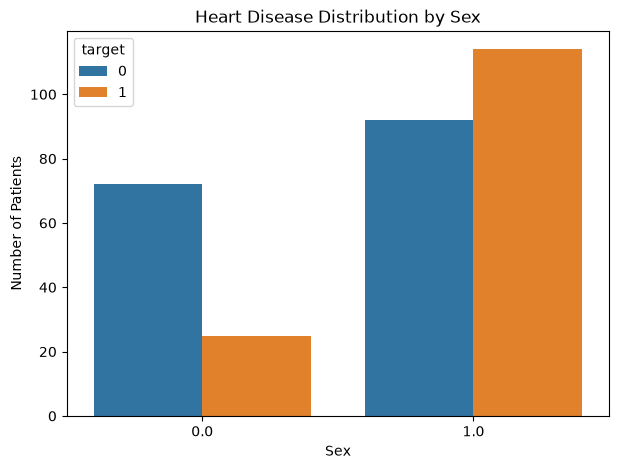

In [112]:
plt.figure(figsize=(7, 5))

sns.countplot(x="sex", hue="target", data=df)

plt.title("Heart Disease Distribution by Sex")
plt.xlabel("Sex")
plt.ylabel("Number of Patients")

plt.show()

In [113]:
print(pd.crosstab(df["cp"], df["target"]))

target   0    1
cp             
1.0     16    7
2.0     41    9
3.0     68   18
4.0     39  105


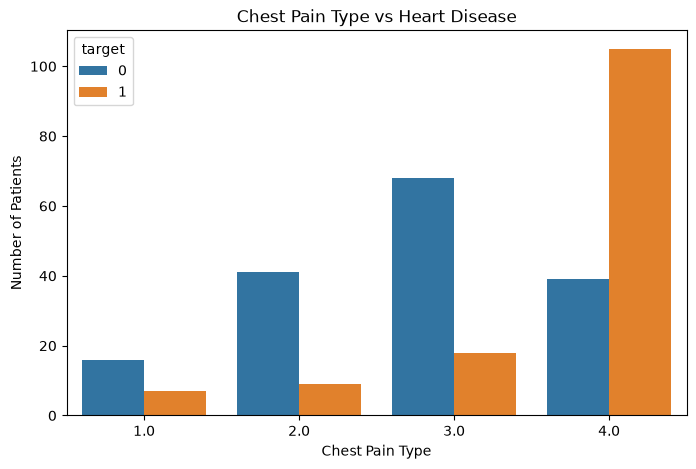

In [114]:
plt.figure(figsize=(8, 5))

sns.countplot(x="cp", hue="target", data=df)

plt.title("Chest Pain Type vs Heart Disease")
plt.xlabel("Chest Pain Type")
plt.ylabel("Number of Patients")

plt.show()

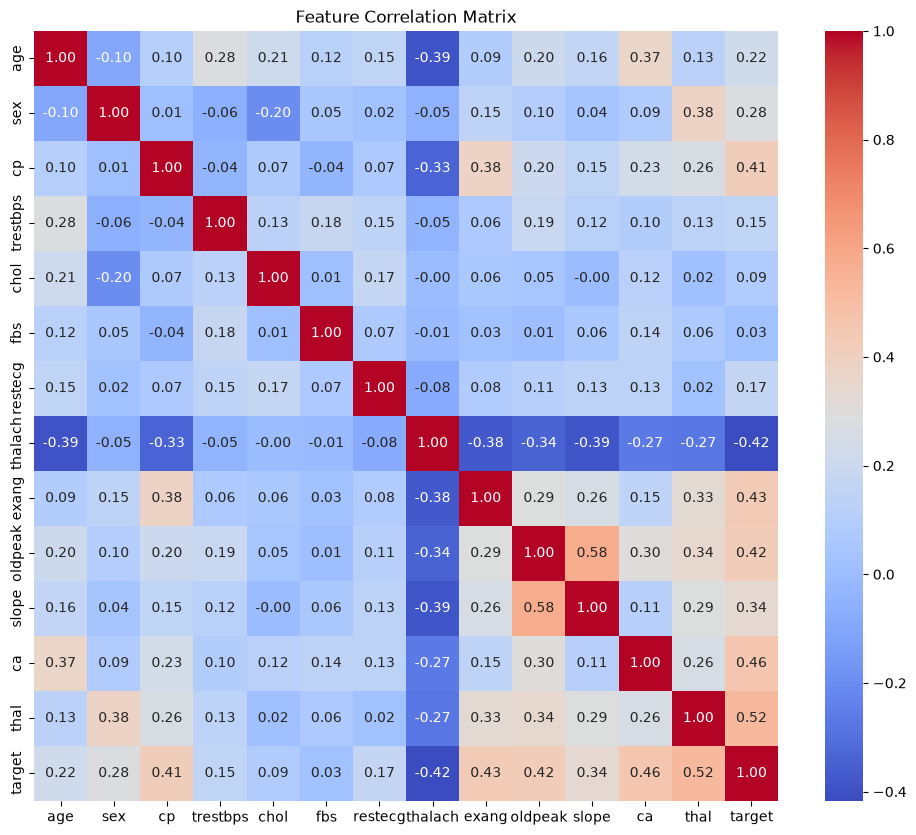

In [115]:
plt.figure(figsize=(12, 10))

correlation = df.corr()

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Feature Correlation Matrix")

plt.show()

In [116]:
target_corr = df.corr()["target"].sort_values(ascending=False)

print(target_corr)

target      1.000000
thal        0.522057
ca          0.460033
exang       0.431894
oldpeak     0.424510
cp          0.414446
slope       0.339213
sex         0.276816
age         0.223120
restecg     0.169202
trestbps    0.150825
chol        0.085164
fbs         0.025264
thalach    -0.417167
Name: target, dtype: float64


In [117]:
print(df.describe().T)

          count        mean        std    min    25%    50%    75%    max
age       303.0   54.438944   9.038662   29.0   48.0   56.0   61.0   77.0
sex       303.0    0.679868   0.467299    0.0    0.0    1.0    1.0    1.0
cp        303.0    3.158416   0.960126    1.0    3.0    3.0    4.0    4.0
trestbps  303.0  131.689769  17.599748   94.0  120.0  130.0  140.0  200.0
chol      303.0  246.693069  51.776918  126.0  211.0  241.0  275.0  564.0
fbs       303.0    0.148515   0.356198    0.0    0.0    0.0    0.0    1.0
restecg   303.0    0.990099   0.994971    0.0    0.0    1.0    2.0    2.0
thalach   303.0  149.607261  22.875003   71.0  133.5  153.0  166.0  202.0
exang     303.0    0.326733   0.469794    0.0    0.0    0.0    1.0    1.0
oldpeak   303.0    1.039604   1.161075    0.0    0.0    0.8    1.6    6.2
slope     303.0    1.600660   0.616226    1.0    1.0    2.0    2.0    3.0
ca        303.0    0.663366   0.934375    0.0    0.0    0.0    1.0    3.0
thal      303.0    4.722772   1.938383

Feature Scaling

In [118]:
X = df.drop("target", axis=1)
y = df["target"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (303, 13)
Target shape: (303,)


In [119]:
print("Feature columns:")
print(X.columns.tolist())

Feature columns:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [120]:
print("X:")
display(X.head())

print("\ny:")
display(y.head())

X:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0



y:


0    0
1    1
2    1
3    0
4    0
Name: target, dtype: int64

In [121]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (242, 13)
Testing features: (61, 13)
Training target: (242,)
Testing target: (61,)


In [122]:
random_state=42

In [123]:
print("Training target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training target distribution:
target
0    0.541322
1    0.458678
Name: proportion, dtype: float64

Testing target distribution:
target
0    0.540984
1    0.459016
Name: proportion, dtype: float64


In [124]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [125]:
scaler.fit_transform(X_train)

array([[-0.72948484,  0.68313005,  0.8701687 , ...,  0.67505958,
        -0.68971531,  1.17997269],
       [ 0.05016647,  0.68313005, -1.18427838, ..., -0.9585846 ,
        -0.68971531, -0.87806977],
       [-0.06121229, -1.46385011, -1.18427838, ..., -0.9585846 ,
         0.44573438, -0.87806977],
       ...,
       [ 1.38671155,  0.68313005,  0.8701687 , ...,  0.67505958,
         1.58118408,  1.17997269],
       [ 1.60946907,  0.68313005, -0.15705484, ...,  0.67505958,
         2.71663377,  1.17997269],
       [-0.72948484,  0.68313005, -1.18427838, ...,  2.30870375,
        -0.68971531,  1.17997269]], shape=(242, 13))

In [126]:
scaler.transform(X_test)

array([[ 4.95681494e-01,  6.83130051e-01,  8.70168699e-01,
         4.00391281e-01,  4.01253955e-01, -4.11195970e-01,
         1.02299580e+00,  1.41509977e+00, -6.96177116e-01,
        -8.91627350e-01, -9.58584599e-01, -6.89715311e-01,
        -8.78069766e-01],
       [ 1.27533279e+00,  6.83130051e-01,  8.70168699e-01,
         1.65137906e+00, -4.14104111e-01, -4.11195970e-01,
         1.02299580e+00, -5.28403693e-01, -6.96177116e-01,
         1.16081179e+00, -9.58584599e-01, -6.89715311e-01,
         6.65462074e-01],
       [-3.95348564e-01, -1.46385011e+00, -1.57054838e-01,
        -5.45133669e-02,  1.16826723e-01, -4.11195970e-01,
         1.02299580e+00, -4.25278274e-02, -6.96177116e-01,
        -4.45444929e-01, -9.58584599e-01, -6.89715311e-01,
        -8.78069766e-01],
       [-2.28878744e+00,  6.83130051e-01, -2.21150191e+00,
        -7.36870338e-01, -1.28634762e+00, -4.11195970e-01,
         1.02299580e+00,  1.06173550e+00, -6.96177116e-01,
        -8.91627350e-01, -9.58584599e

In [127]:
print("Original training data:")
print(X_train.head())

print("\nScaled training data:")
print(X_train_scaled[:5])

Original training data:
      age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
180  48.0  1.0  4.0     124.0  274.0  0.0      2.0    166.0    0.0      0.5   
208  55.0  1.0  2.0     130.0  262.0  0.0      0.0    155.0    0.0      0.0   
167  54.0  0.0  2.0     132.0  288.0  1.0      2.0    159.0    1.0      0.0   
105  54.0  1.0  2.0     108.0  309.0  0.0      0.0    156.0    0.0      0.0   
297  57.0  0.0  4.0     140.0  241.0  0.0      0.0    123.0    1.0      0.2   

     slope   ca  thal  
180    2.0  0.0   7.0  
208    1.0  0.0   3.0  
167    1.0  1.0   3.0  
105    1.0  0.0   7.0  
297    2.0  0.0   7.0  

Scaled training data:
[[-0.72948484  0.68313005  0.8701687  -0.39569185  0.4581394  -0.41119597
   1.0229958   0.70837124 -0.69617712 -0.44544493  0.67505958 -0.68971531
   1.17997269]
 [ 0.05016647  0.68313005 -1.18427838 -0.05451337  0.23059762 -0.41119597
  -0.98157896  0.22249537 -0.69617712 -0.89162735 -0.9585846  -0.68971531
  -0.87806977]
 [-0.061

In [128]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (242, 13)
X_test: (61, 13)
X_train_scaled: (242, 13)
X_test_scaled: (61, 13)
y_train: (242,)
y_test: (61,)


In [129]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X shape: (303, 13)
y shape: (303,)
X_train: (242, 13)
X_test: (61, 13)


Step 5 : Train Model

In [130]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

print("Model training completed!")

Model training completed!


In [131]:
y_pred = model.predict(X_test_scaled)

print("Predictions created!")
print(y_pred)

Predictions created!
[0 1 0 0 1 0 0 0 1 0 1 0 0 1 1 1 1 0 1 1 1 0 1 1 1 0 0 1 0 1 0 1 1 0 0 1 0
 0 0 1 1 1 1 1 0 0 1 0 1 0 0 1 1 0 0 1 1 1 0 0 1]


In [132]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print(comparison.head(15))

    Actual  Predicted
0        0          0
1        0          1
2        0          0
3        0          0
4        0          1
5        0          0
6        0          0
7        0          0
8        1          1
9        0          0
10       1          1
11       0          0
12       0          0
13       1          1
14       1          1


In [133]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.8688524590163934
Accuracy (%): 86.88524590163934


In [134]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[27  6]
 [ 2 26]]


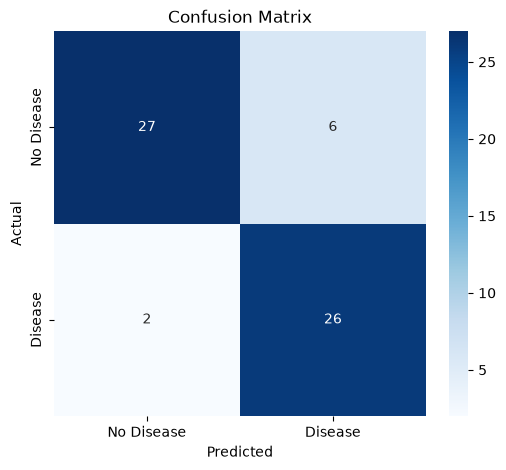

In [135]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [136]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["No Disease", "Disease"]
))

              precision    recall  f1-score   support

  No Disease       0.93      0.82      0.87        33
     Disease       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



In [137]:
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print(y_prob[:10])

[0.21774605 0.70863903 0.05831754 0.03684567 0.53639431 0.02422394
 0.11950744 0.2205262  0.80863288 0.31361207]


In [138]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", auc)

ROC-AUC: 0.9512987012987013


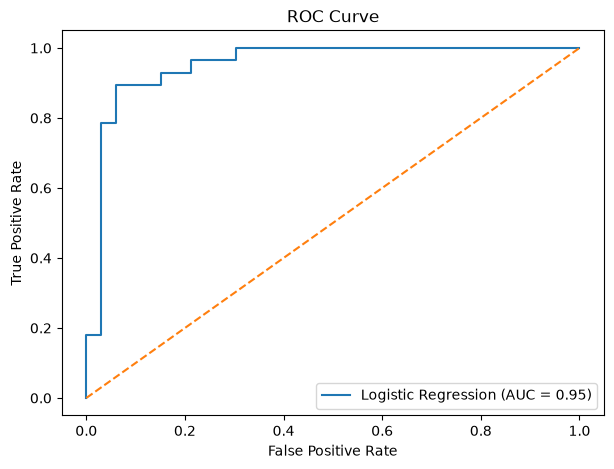

In [139]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))

plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

In [140]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("Model Performance")
print("-------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")

Model Performance
-------------------------
Accuracy : 0.8689
Precision: 0.8125
Recall   : 0.9286
F1 Score : 0.8667
ROC-AUC  : 0.9513


In [141]:
import joblib

joblib.dump(model, "../models/heart_disease_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [142]:
joblib.dump(scaler, "../models/scaler.pkl")

print("Scaler saved successfully!")

Scaler saved successfully!


In [143]:
print(confusion_matrix(y_test, y_pred))

[[27  6]
 [ 2 26]]


ML Model comparison

In [144]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

print("All models imported successfully!")


All models imported successfully!


In [145]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "SVM": SVC(
        probability=True,
        random_state=42
    )
}

print("Models created successfully!")


Models created successfully!


In [146]:
trained_models = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    
    print(name, "trained successfully")

Logistic Regression trained successfully
Decision Tree trained successfully
Random Forest trained successfully
KNN trained successfully
SVM trained successfully


c:\Users\BITPATNA\OneDrive\Desktop\heart-disease-ai\venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Make predictions

In [147]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results = []

for name, model in trained_models.items():

    y_pred_model = predictions[name]

    # Probability of Disease class
    y_prob_model = model.predict_proba(X_test_scaled)[:, 1]

    accuracy = accuracy_score(y_test, y_pred_model)
    precision = precision_score(y_test, y_pred_model)
    recall = recall_score(y_test, y_pred_model)
    f1 = f1_score(y_test, y_pred_model)
    auc = roc_auc_score(y_test, y_prob_model)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": auc
    })

print("Metrics calculated successfully!")

NameError: name 'predictions' is not defined

In [ ]:
results_df = pd.DataFrame(results)

print(results_df.round(4))

                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
0  Logistic Regression    0.8689     0.8125  0.9286    0.8667   0.9513
1        Decision Tree    0.7213     0.6571  0.8214    0.7302   0.7289
2        Random Forest    0.9016     0.8438  0.9643    0.9000   0.9551
3                  KNN    0.8852     0.8000  1.0000    0.8889   0.9232
4                  SVM    0.8525     0.8065  0.8929    0.8475   0.9437


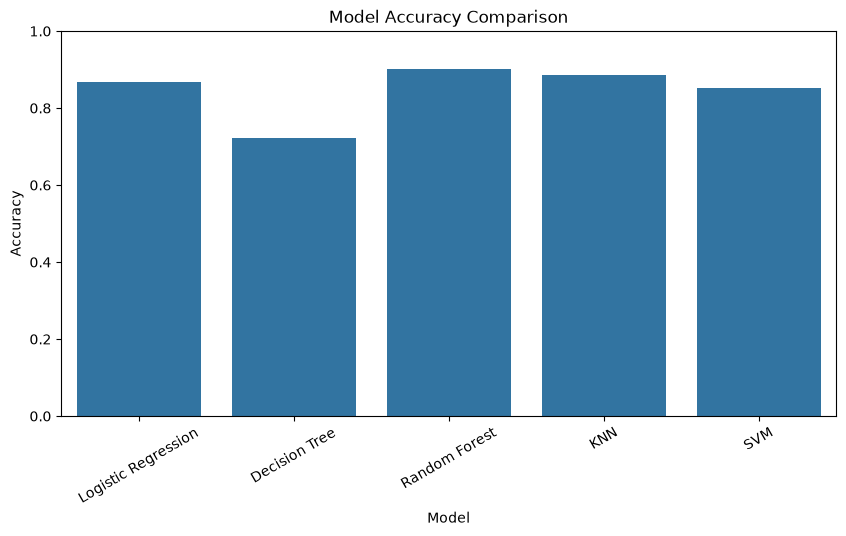

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.xticks(rotation=30)
plt.ylim(0, 1)

plt.show()

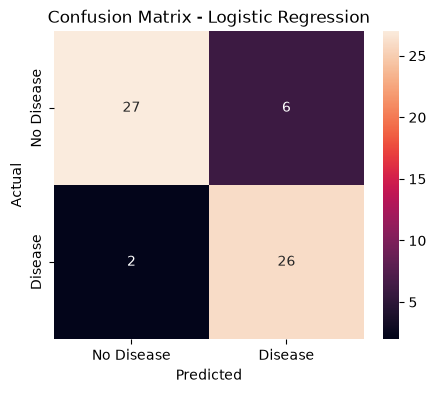

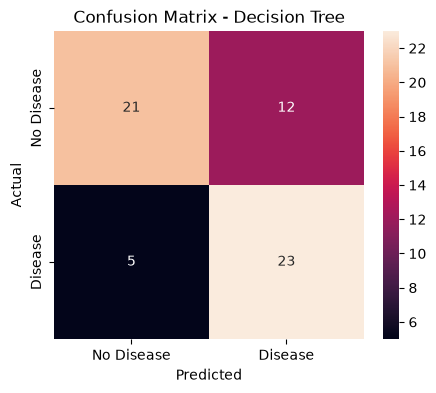

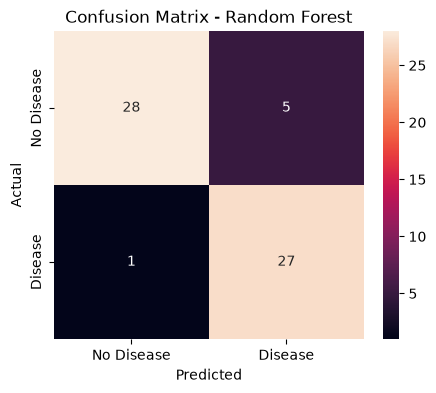

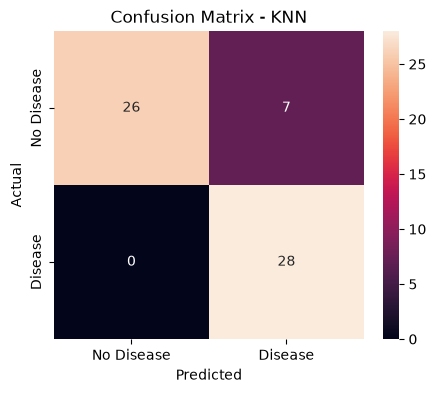

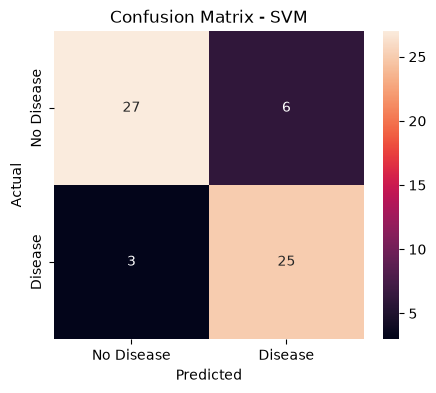

In [ ]:
from sklearn.metrics import confusion_matrix

for name, y_pred_model in predictions.items():

    cm = confusion_matrix(y_test, y_pred_model)

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=["No Disease", "Disease"],
        yticklabels=["No Disease", "Disease"]
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

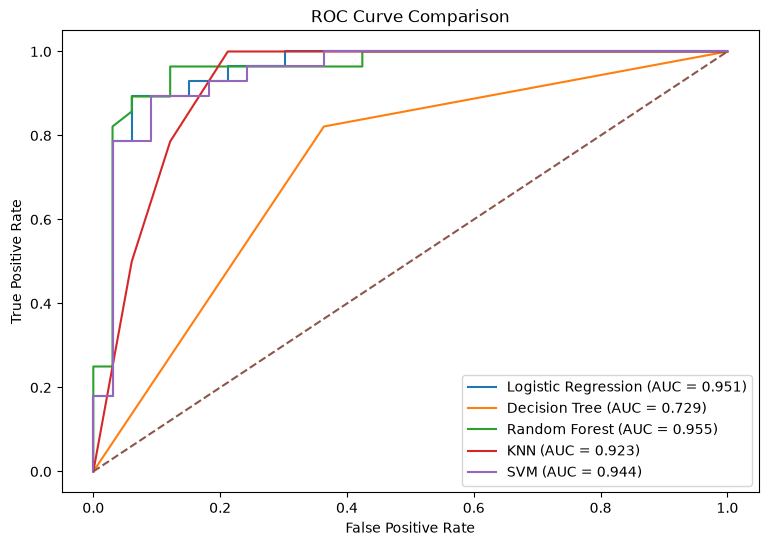

In [ ]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(9, 6))

for name, model in trained_models.items():

    y_prob_model = model.predict_proba(X_test_scaled)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob_model)

    auc = roc_auc_score(y_test, y_prob_model)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

In [ ]:
print(
    results_df
    .sort_values("Accuracy", ascending=False)
    .round(4)
)

                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
2        Random Forest    0.9016     0.8438  0.9643    0.9000   0.9551
3                  KNN    0.8852     0.8000  1.0000    0.8889   0.9232
0  Logistic Regression    0.8689     0.8125  0.9286    0.8667   0.9513
4                  SVM    0.8525     0.8065  0.8929    0.8475   0.9437
1        Decision Tree    0.7213     0.6571  0.8214    0.7302   0.7289


In [ ]:
print(
    results_df
    .sort_values("Recall", ascending=False)
    .round(4)
)

                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
3                  KNN    0.8852     0.8000  1.0000    0.8889   0.9232
2        Random Forest    0.9016     0.8438  0.9643    0.9000   0.9551
0  Logistic Regression    0.8689     0.8125  0.9286    0.8667   0.9513
4                  SVM    0.8525     0.8065  0.8929    0.8475   0.9437
1        Decision Tree    0.7213     0.6571  0.8214    0.7302   0.7289


In [ ]:
results_df.to_csv(
    "../models/model_comparison.csv",
    index=False
)

print("Model comparison saved successfully!")

Model comparison saved successfully!


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

print("Cross-validation tools imported!")

Cross-validation tools imported!


In [ ]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("5-fold cross-validation created!")

5-fold cross-validation created!


In [ ]:
cv_results = []

for name, model in models.items():

    scores = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=cv,
        scoring="accuracy"
    )

    cv_results.append({
        "Model": name,
        "Mean Accuracy": scores.mean(),
        "Std Accuracy": scores.std()
    })

    print(f"\n{name}")
    print("Fold scores:", scores)
    print("Mean:", scores.mean())
    print("Std:", scores.std())

cv_results_df = pd.DataFrame(cv_results)

print(cv_results_df.round(4))


Logistic Regression
Fold scores: [0.85714286 0.81632653 0.8125     0.8125     0.83333333]
Mean: 0.8263605442176871
Std: 0.01721093476909073

Decision Tree
Fold scores: [0.73469388 0.71428571 0.6875     0.66666667 0.6875    ]
Mean: 0.6981292517006803
Std: 0.023722813438934003

Random Forest
Fold scores: [0.83673469 0.79591837 0.8125     0.8125     0.79166667]
Mean: 0.8098639455782314
Std: 0.01588429911569802

KNN
Fold scores: [0.85714286 0.79591837 0.83333333 0.77083333 0.83333333]
Mean: 0.8181122448979592
Std: 0.030707052733897906

SVM
Fold scores: [0.85714286 0.79591837 0.79166667 0.83333333 0.83333333]
Mean: 0.8222789115646257
Std: 0.02486717921963843
                 Model  Mean Accuracy  Std Accuracy
0  Logistic Regression         0.8264        0.0172
1        Decision Tree         0.6981        0.0237
2        Random Forest         0.8099        0.0159
3                  KNN         0.8181        0.0307
4                  SVM         0.8223        0.0249


c:\Users\BITPATNA\OneDrive\Desktop\heart-disease-ai\venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\BITPATNA\OneDrive\Desktop\heart-disease-ai\venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\BITPATNA\OneDrive\Desktop\heart-disease-ai\venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\BITPATNA\OneDrive\Desktop\heart-disease-ai\venv\Lib\site-packages\skle

In [ ]:
cv_results_df = pd.DataFrame(cv_results)

print(cv_results_df.round(4))

                 Model  Mean Accuracy  Std Accuracy
0  Logistic Regression         0.8264        0.0172
1        Decision Tree         0.6981        0.0237
2        Random Forest         0.8099        0.0159
3                  KNN         0.8181        0.0307
4                  SVM         0.8223        0.0249


In [ ]:
cv_auc_results = []

for name, model in models.items():

    scores = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=cv,
        scoring="roc_auc"
    )

    cv_auc_results.append({
        "Model": name,
        "Mean ROC-AUC": scores.mean(),
        "Std ROC-AUC": scores.std()
    })

cv_auc_df = pd.DataFrame(cv_auc_results)

print(cv_auc_df.round(4))

                 Model  Mean ROC-AUC  Std ROC-AUC
0  Logistic Regression        0.8960       0.0148
1        Decision Tree        0.6967       0.0217
2        Random Forest        0.8832       0.0321
3                  KNN        0.8861       0.0224
4                  SVM        0.8828       0.0250


c:\Users\BITPATNA\OneDrive\Desktop\heart-disease-ai\venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\BITPATNA\OneDrive\Desktop\heart-disease-ai\venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\BITPATNA\OneDrive\Desktop\heart-disease-ai\venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\BITPATNA\OneDrive\Desktop\heart-disease-ai\venv\Lib\site-packages\skle

In [150]:
cv_recall_results = []

for name, model in models.items():

    scores = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=cv,
        scoring="recall"
    )

    cv_recall_results.append({
        "Model": name,
        "Mean Recall": scores.mean(),
        "Std Recall": scores.std()
    })

cv_recall_df = pd.DataFrame(cv_recall_results)

print(cv_recall_df.round(4))

                 Model  Mean Recall  Std Recall
0  Logistic Regression       0.7652      0.0547
1        Decision Tree       0.6842      0.0595
2        Random Forest       0.7557      0.0756
3                  KNN       0.7921      0.0562
4                  SVM       0.7561      0.0903


c:\Users\BITPATNA\OneDrive\Desktop\heart-disease-ai\venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\BITPATNA\OneDrive\Desktop\heart-disease-ai\venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\BITPATNA\OneDrive\Desktop\heart-disease-ai\venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\BITPATNA\OneDrive\Desktop\heart-disease-ai\venv\Lib\site-packages\skle

In [151]:
cv_recall_df = pd.DataFrame(cv_recall_results)

print(cv_recall_df.round(4))

                 Model  Mean Recall  Std Recall
0  Logistic Regression       0.7652      0.0547
1        Decision Tree       0.6842      0.0595
2        Random Forest       0.7557      0.0756
3                  KNN       0.7921      0.0562
4                  SVM       0.7561      0.0903


In [152]:
cv_summary = cv_results_df.merge(
    cv_auc_df,
    on="Model"
).merge(
    cv_recall_df,
    on="Model"
)

print(cv_summary.round(4))

                 Model  Mean Accuracy  Std Accuracy  Mean ROC-AUC  \
0  Logistic Regression         0.8264        0.0172        0.8960   
1        Decision Tree         0.6981        0.0237        0.6967   
2        Random Forest         0.8099        0.0159        0.8832   
3                  KNN         0.8181        0.0307        0.8861   
4                  SVM         0.8223        0.0249        0.8828   

   Std ROC-AUC  Mean Recall  Std Recall  
0       0.0148       0.7652      0.0547  
1       0.0217       0.6842      0.0595  
2       0.0321       0.7557      0.0756  
3       0.0224       0.7921      0.0562  
4       0.0250       0.7561      0.0903  


HyperTunning

In [153]:
from sklearn.model_selection import GridSearchCV

print("GridSearchCV imported!")

GridSearchCV imported!


Define parameter grids

In [154]:
param_grids = {

    "Logistic Regression": {
        "C": [0.01, 0.1, 1, 10, 100]
    },

    "Decision Tree": {
        "max_depth": [2, 3, 4, 5, 6, 8, 10],
        "min_samples_split": [2, 5, 10]
    },

    "Random Forest": {
        "n_estimators": [100, 200, 300],
        "max_depth": [None, 3, 5, 8, 10],
        "min_samples_split": [2, 5, 10]
    },

    "KNN": {
        "n_neighbors": [3, 5, 7, 9, 11],
        "weights": ["uniform", "distance"]
    },

    "SVM": {
        "C": [0.1, 1, 10, 100],
        "kernel": ["linear", "rbf"],
        "gamma": ["scale", "auto"]
    }
}

print("Parameter grids created!")

Parameter grids created!


Run GridSearchCV

In [155]:
tuned_models = {}

for name, model in models.items():

    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )

    grid_search.fit(X_train_scaled, y_train)

    tuned_models[name] = grid_search.best_estimator_

    print("\n", name)
    print("Best Parameters:", grid_search.best_params_)
    print("Best ROC-AUC:", grid_search.best_score_)


 Logistic Regression
Best Parameters: {'C': 0.1}
Best ROC-AUC: 0.8993761472022342

 Decision Tree
Best Parameters: {'max_depth': 3, 'min_samples_split': 2}
Best ROC-AUC: 0.8306912491695101

 Random Forest
Best Parameters: {'max_depth': 3, 'min_samples_split': 5, 'n_estimators': 300}
Best ROC-AUC: 0.8928076754163712

 KNN
Best Parameters: {'n_neighbors': 11, 'weights': 'uniform'}
Best ROC-AUC: 0.9001517403691317

 SVM
Best Parameters: {'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}
Best ROC-AUC: 0.8964505703636139


c:\Users\BITPATNA\OneDrive\Desktop\heart-disease-ai\venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Compare the tuned models

In [157]:
tuned_results = []

for name, model in tuned_models.items():

    y_pred_tuned = model.predict(X_test_scaled)
    y_prob_tuned = model.predict_proba(X_test_scaled)[:, 1]

    tuned_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred_tuned),
        "Precision": precision_score(y_test, y_pred_tuned),
        "Recall": recall_score(y_test, y_pred_tuned),
        "F1 Score": f1_score(y_test, y_pred_tuned),
        "ROC-AUC": roc_auc_score(y_test, y_prob_tuned)
    })

tuned_results_df = pd.DataFrame(tuned_results)

print(tuned_results_df.round(4))

                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
0  Logistic Regression    0.8525     0.8065  0.8929    0.8475   0.9578
1        Decision Tree    0.8689     0.8571  0.8571    0.8571   0.8712
2        Random Forest    0.9180     0.8966  0.9286    0.9123   0.9632
3                  KNN    0.8852     0.8182  0.9643    0.8852   0.9610
4                  SVM    0.8852     0.8621  0.8929    0.8772   0.9470


Save the tuning results

In [158]:
tuned_results_df.to_csv(
    "../models/tuned_model_results.csv",
    index=False
)

print("Tuned model results saved!")

Tuned model results saved!


Check the results

In [159]:
print(tuned_results_df.round(4))

                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
0  Logistic Regression    0.8525     0.8065  0.8929    0.8475   0.9578
1        Decision Tree    0.8689     0.8571  0.8571    0.8571   0.8712
2        Random Forest    0.9180     0.8966  0.9286    0.9123   0.9632
3                  KNN    0.8852     0.8182  0.9643    0.8852   0.9610
4                  SVM    0.8852     0.8621  0.8929    0.8772   0.9470


Find the model with highest ROC-AUC

In [160]:
best_model_name = tuned_results_df.loc[
    tuned_results_df["ROC-AUC"].idxmax(),
    "Model"
]

print("Selected model:", best_model_name)

Selected model: Random Forest


Get the selected model

In [161]:
final_model = tuned_models[best_model_name]

print("Final model:")
print(final_model)

Final model:
RandomForestClassifier(max_depth=3, min_samples_split=5, n_estimators=300,
                       random_state=42)


Check final model performance

In [162]:
y_pred_final = final_model.predict(X_test_scaled)
y_prob_final = final_model.predict_proba(X_test_scaled)[:, 1]

print("Final Model Performance")
print("-----------------------")
print("Accuracy :", accuracy_score(y_test, y_pred_final))
print("Precision:", precision_score(y_test, y_pred_final))
print("Recall   :", recall_score(y_test, y_pred_final))
print("F1 Score :", f1_score(y_test, y_pred_final))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_final))

Final Model Performance
-----------------------
Accuracy : 0.9180327868852459
Precision: 0.896551724137931
Recall   : 0.9285714285714286
F1 Score : 0.9122807017543859
ROC-AUC  : 0.9632034632034632


In [163]:
import joblib

joblib.dump(
    final_model,
    "../models/heart_disease_model.pkl"
)

print("Final model saved successfully!")

Final model saved successfully!


In [164]:
joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

print("Scaler saved successfully!")

Scaler saved successfully!


Save the model name and metrics

In [165]:
import json

final_metrics = {
    "model": best_model_name,
    "accuracy": float(accuracy_score(y_test, y_pred_final)),
    "precision": float(precision_score(y_test, y_pred_final)),
    "recall": float(recall_score(y_test, y_pred_final)),
    "f1_score": float(f1_score(y_test, y_pred_final)),
    "roc_auc": float(roc_auc_score(y_test, y_prob_final))
}

with open("../models/final_model_metrics.json", "w") as f:
    json.dump(final_metrics, f, indent=4)

print("Final model metrics saved!")

Final model metrics saved!


In [166]:
import os

print(os.listdir("../models"))

['final_model_metrics.json', 'heart_disease_model.pkl', 'model_comparison.csv', 'scaler.pkl', 'tuned_model_results.csv']


In [167]:
print("Selected model:", best_model_name)
print(final_model)

Selected model: Random Forest
RandomForestClassifier(max_depth=3, min_samples_split=5, n_estimators=300,
                       random_state=42)
